In [1]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.base import clone

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score

In [3]:
pd.set_option('display.max_columns', None)
X_train = pd.read_csv('data/train075_no_apache.csv')
y_train = pd.read_csv('data/Ytrain075.csv').squeeze()
X_test = pd.read_csv('data/test_no_apache.csv').squeeze()
y_test = pd.read_csv('data/y_test.csv')
X_train.head(5)

,age,elective_surgery,gender,height,pre_icu_los_days,weight,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,ethnicity_African American,ethnicity_Asian,ethnicity_Caucasian,ethnicity_Hispanic,ethnicity_Native American,ethnicity_Other/Unknown,ethnicity_missing,hospital_admit_source_Acute Care/Floor,hospital_admit_source_Chest Pain Center,hospital_admit_source_Direct Admit,hospital_admit_source_Emergency Department,hospital_admit_source_Floor,hospital_admit_source_ICU,hospital_admit_source_ICU to SDU,hospital_admit_source_Observation,hospital_admit_source_Operating Room,hospital_admit_source_Other,hospital_admit_source_Other Hospital,hospital_admit_source_Other ICU,hospital_admit_source_PACU,hospital_admit_source_Recovery Room,hospital_admit_source_Step-Down Unit (SDU),hospital_admit_source_missing,icu_admit_source_Accident & Emergency,icu_admit_source_Floor,icu_admit_source_Other Hospital,icu_admit_source_Other ICU,icu_admit_source_missing,icu_stay_type_admit,icu_stay_type_readmit,icu_stay_type_transfer,icu_type_CCU-CTICU,icu_type_CSICU,icu_type_CTICU,icu_type_Cardiac ICU,icu_type_MICU,icu_type_Med-Surg ICU,icu_type_Neuro ICU,icu_type_SICU,d1_heartrate_range,d1_mbp_range,d1_resprate_range,d1_spo2_range,d1_sysbp_range,d1_temp_range,h1_diasbp_range,h1_heartrate_range,h1_mbp_range,h1_resprate_range,h1_spo2_range,h1_sysbp_range,h1_temp_range,d1_albumin_range,d1_bilirubin_range,d1_bun_range,d1_calcium_range,d1_creatinine_range,d1_glucose_range,d1_hco3_range,d1_hemaglobin_range,d1_platelets_range,d1_potassium_range,d1_sodium_range,d1_wbc_range,h1_glucose_range
0,74.0,0.0,1.0,178.0,0.259722,70.4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,42.0,33.0,17.0,7.0,40.0,0.7,17.0,16.0,16.0,3.0,5.0,19.0,0.1,0.1,0.1,0.0,0.0,0.00,0.0,0.0,4.6,15.0,0.0,0.0,0.7,6.0
1,66.0,0.0,0.0,162.0,0.052778,58.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,21.0,28.0,51.0,9.0,39.0,1.3,9.0,8.0,5.0,16.0,2.0,7.0,0.0,0.1,0.1,0.0,0.0,0.00,0.0,0.0,0.5,10.0,1.5,0.0,0.9,6.0
2,64.0,0.0,0.0,170.2,0.355556,113.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,20.0,95.0,16.0,5.0,109.0,0.5,26.0,14.0,40.0,8.0,4.0,29.0,0.0,0.0,0.0,0.0,0.0,0.00,118.0,0.0,0.5,10.0,0.0,0.0,0.9,6.0
3,77.0,0.0,1.0,182.9,0.035417,86.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,21.0,22.0,13.0,6.0,52.0,0.2,11.0,7.0,10.0,6.0,0.0,24.0,0.0,0.1,0.1,1.0,0.2,0.05,136.0,1.0,0.5,10.0,0.0,1.0,0.9,6.0
4,42.0,0.0,1.0,170.1,0.147917,85.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,34.0,26.0,12.0,2.0,29.0,0.5,19.0,17.0,18.0,9.0,2.0,23.0,0.1,0.1,0.1,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0


In [4]:
params = {'max_depth': [10, 20, 30, 40],
          'booster': ['gbtree'],
          'subsample': [0.7, 0.8, 0.9],
          'n_estimators': [300, 400, 500],
          'learning_rate': [0.1, 0.15, 0.2],
          'min_child_weight': [1, 2]
          }

xgb = XGBClassifier(random_state = 24, eval_metric = 'logloss')

fold = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 24)

search = RandomizedSearchCV(
    estimator = xgb,
    param_distributions = params,
    n_iter = 70,
    scoring = 'f1',
    cv = fold,
    verbose = 2,
    n_jobs = -1,
    random_state = 24
)

search.fit(X_train, y_train)

y_proba = search.predict_proba(X_test)[:,1]
y_pred = search.predict(X_test)

Fitting 5 folds for each of 70 candidates, totalling 350 fits
[CV] END booster=gbtree, learning_rate=0.2, max_depth=40, min_child_weight=1, n_estimators=400, subsample=0.9; total time=  26.2s
[CV] END booster=gbtree, learning_rate=0.2, max_depth=40, min_child_weight=1, n_estimators=400, subsample=0.9; total time=  24.7s
[CV] END booster=gbtree, learning_rate=0.2, max_depth=40, min_child_weight=1, n_estimators=400, subsample=0.9; total time=  22.5s
[CV] END booster=gbtree, learning_rate=0.2, max_depth=40, min_child_weight=1, n_estimators=400, subsample=0.9; total time=  22.5s
[CV] END booster=gbtree, learning_rate=0.2, max_depth=40, min_child_weight=1, n_estimators=400, subsample=0.9; total time=  22.6s
[CV] END booster=gbtree, learning_rate=0.1, max_depth=20, min_child_weight=1, n_estimators=300, subsample=0.8; total time=  23.9s
[CV] END booster=gbtree, learning_rate=0.1, max_depth=20, min_child_weight=1, n_estimators=300, subsample=0.8; total time=  23.2s
[CV] END booster=gbtree, lea

In [5]:
print(search.best_params_)

{'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 20, 'learning_rate': 0.1, 'booster': 'gbtree'}


Accuracy: 91.18%
Recall: 26.48%
Precision: 49.66%
F1: 34.54%


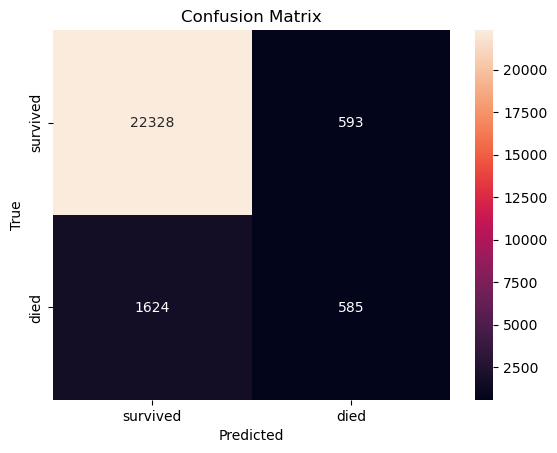

In [6]:
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print('Accuracy: %.2f%%' % (accuracy * 100.0))
print('Recall: %.2f%%' % (recall * 100.0))
print('Precision: %.2f%%' % (precision * 100.0))
print('F1: %.2f%%' % (f1 * 100.0))

matrix = confusion_matrix(y_test, y_pred)
ax = plt.subplot()
sns.heatmap(matrix, annot = True, fmt = 'g', ax = ax);

ax.set_xlabel('Predicted');
ax.set_ylabel('True');
ax.set_title('Confusion Matrix');
ax.xaxis.set_ticklabels(['survived', 'died']);
ax.yaxis.set_ticklabels(['survived', 'died']);

In [7]:
matrix

array([[22328,   593],
       [ 1624,   585]])

AUC: 0.8155725072097483


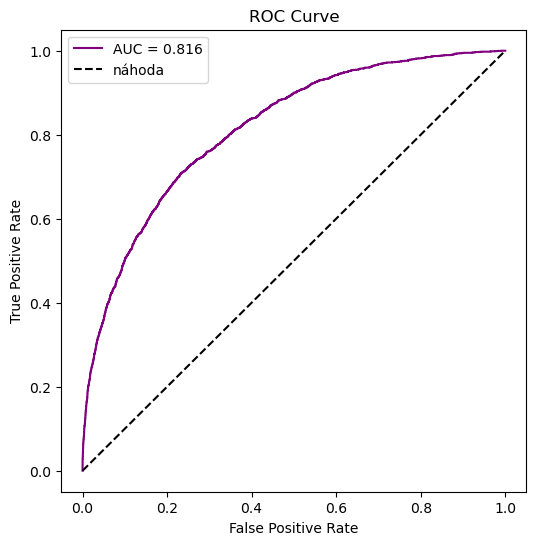

In [8]:
auc = roc_auc_score(y_test, y_proba)
print("AUC:", auc)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}', color = 'purple')
plt.plot([0,1], [0,1], 'k--', label='náhoda')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [14]:
fold = StratifiedKFold(n_splits =  5, shuffle = True, random_state = 24)

oof_proba = np.zeros(len(X_train))
oof_y = y_train.values 

best_model = search.best_estimator_

for train_idx, val_idx in fold.split(X_train, y_train):
    
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    model = clone(best_model)
    
    model.fit(X_tr, y_tr)
    
    oof_proba[val_idx] = model.predict_proba(X_val)[:, 1]

In [15]:
thresholds = [0.4, 0.45, 0.5, 0.55, 0.6]

best_t = 0
best_score = 0

for t in thresholds:
    y_pred = (oof_proba >= t).astype(int)
    recall = recall_score(oof_y, y_pred)
    precision = precision_score(oof_y, y_pred)
    f1 = f1_score(oof_y, y_pred)
    
    print(
        t,
        'recall:', recall,
        'precision:', precision,
        'f1:', f1
        
    )
    
    score = 0.7 * recall + 0.3* precision

    if score > best_score:
        best_score = score
        best_t = t

print('Best threshold:', best_t)
print('Best score:', best_score)

0.4 recall: 0.9939418869900153 precision: 0.9423506470483957 f1: 0.967458959705893
0.45 recall: 0.9936053251561273 precision: 0.9489963568826345 f1: 0.970788651601235
0.5 recall: 0.9933809506002019 precision: 0.9549556026890031 f1: 0.9737893617801239
0.55 recall: 0.993006993006993 precision: 0.960848169054856 f1: 0.9766629273406036
0.6 recall: 0.9929695972476721 precision: 0.9652828268140178 f1: 0.9789304871979208
Best threshold: 0.6
Best score: 0.9846635661175758


In [16]:
y_pred_test = (y_proba >= best_t).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.93      0.98      0.95     22921
           1       0.55      0.23      0.33      2209

    accuracy                           0.92     25130
   macro avg       0.74      0.61      0.64     25130
weighted avg       0.90      0.92      0.90     25130



Accuracy: 91.55%
Recall: 23.27%
Precision: 54.51%
F1: 32.61%


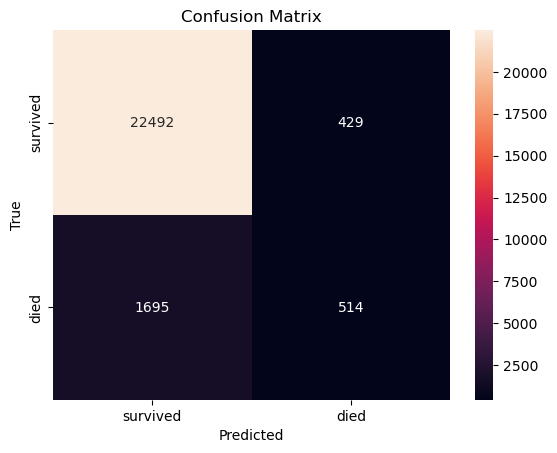

In [17]:
accuracy = accuracy_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)

print('Accuracy: %.2f%%' % (accuracy * 100.0))
print('Recall: %.2f%%' % (recall * 100.0))
print('Precision: %.2f%%' % (precision * 100.0))
print('F1: %.2f%%' % (f1 * 100.0))

matrix = confusion_matrix(y_test, y_pred_test)
ax = plt.subplot()
sns.heatmap(matrix, annot = True, fmt = 'g', ax = ax);

ax.set_xlabel('Predicted');ax.set_ylabel('True');
ax.set_title('Confusion Matrix');
ax.xaxis.set_ticklabels(['survived', 'died']); ax.yaxis.set_ticklabels(['survived', 'died']);

In [18]:
matrix

array([[22492,   429],
       [ 1695,   514]])